# Pointing and Alignment Errors

In this notebook we show how to produce Pointing errors drawn from a normal distribution.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

## User defined parameters

In [18]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
outdir   = '/lhome/nicholas/software/workdir/kul21/input'
ra       = +86.79870508
dec      = -46.39594703
rot      = -4.
sigma    = 3
quarters = np.arange(1,9)

## AOCS (and FGS) pointing errors after each quarter

In [19]:
# Coordinates
ICRS = np.array([ra, dec, rot])

# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600  # Req. directional
b = 6.0/3600  # Req. rotational

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt(f'{outdir}/PRE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

# Print the generated values
print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)
print('\nChange of coordinates [arcsec]')
print(coor*3600)
print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

Yaw, Pitch, and Roll angles
[-0.00230991  0.00025228  0.0020134  -0.00092296  0.00086208  0.00206783
  0.0002721   0.00109881]
[ 5.76348116e-04 -3.24219236e-04 -3.75636515e-04  3.58081922e-04
 -3.73907057e-04 -5.09198688e-04 -3.15860732e-05  3.45122499e-05]
[ 1.72904435e-03 -9.72657707e-04 -1.12690954e-03  1.07424577e-03
 -1.12172117e-03 -1.52759606e-03 -9.47582195e-05  1.03536750e-04]

Change of coordinates [arcsec]
[[ 3.60000000e+03  6.57516680e+00  8.06398342e+00  6.09609072e+00]
 [ 7.20000000e+03 -3.69879852e+00 -7.66601136e-01 -7.03819261e-01]
 [ 1.08000000e+04 -4.28538356e+00 -7.08417036e+00 -5.29509844e+00]
 [ 1.44000000e+04  4.08511506e+00  3.16626210e+00  2.45437941e+00]
 [ 1.80000000e+04 -4.26565334e+00 -2.94018714e+00 -2.29822938e+00]
 [ 2.16000000e+04 -5.80910429e+00 -7.22179130e+00 -5.45621362e+00]
 [ 2.52000000e+04 -3.60344198e-01 -9.65754065e-01 -7.12805102e-01]
 [ 2.88000000e+04  3.93726975e-01 -3.97078843e+00 -2.85493105e+00]]

New coordinates [deg]
86.80053151522335 -

In [9]:
# eps = np.sqrt(2)*rho*np.tan(the/2)

# t = np.sqrt(y**2 + rho**2)
# T = np.sqrt(x**2 - 2*x*rho*np.cos(phi)*np.sin(the) + (rho*np.sin(the))**2)

# print(t)
# print(T)
# print(np.sqrt(3)*eps)

# print(dx)
# print(6/3600 /3)
# # Rotation matrix
# R1 = matrixMisalignment(dx[0], dy[0], dz[0])
# R2 = matrixMisalignment(dx[1], dy[1], dz[1])

# # Transformation (matrix) between P/L to ICRS reference system
# coor1 = np.dot(R1, ICRS)
# coor2 = np.dot(R2, ICRS)
# print(f'{coor1[0]}, {coor1[1]}, {coor1[2]}')
# print(f'{coor2[0]}, {coor2[1]}, {coor2[2]}')

## Camera alignment errors in yaw, pitch, and roll (x, y, z)

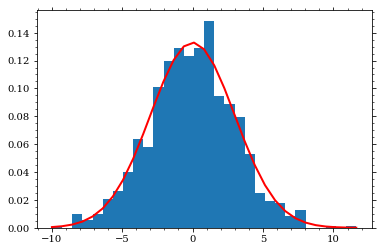

Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]
[[ -1.37801202   0.02127615   4.1553122   -1.37801202  -4.13403605]
 [  1.1289825    1.9158325   -1.47111499   1.1289825    3.38694749]
 [  0.32885292   4.84572813   3.85916938   0.32885292   0.98655875]
 [  1.87722019  -4.66437851 -10.29603907   1.87722019   5.63166056]
 [  0.86006224  -0.3400678   -2.92025452   0.86006224   2.58018671]
 [ -2.15697192   1.93123885   8.4021546   -2.15697192  -6.47091575]
 [ -1.37326357   0.65019141   4.76998213  -1.37326357  -4.11979072]
 [ -2.01583133   8.34344465  14.39093865  -2.01583133  -6.047494  ]
 [ -0.61450617  -3.40465083  -1.56113234  -0.61450617  -1.8435185 ]
 [ -0.05856094  -0.21478685  -0.03910404  -0.05856094  -0.17568282]
 [ -0.37646013  -3.23360669  -2.10422629  -0.37646013  -1.1293804 ]
 [ -1.41259159   0.76111434   4.99888911  -1.41259159  -4.23777477]
 [  0.83532854   2.3005804   -0.20540522   0.83532854   2.50598562]
 [ -1.52109093   0.31243303   4.87570582  -

In [20]:
# Req. Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 4.5/60  # [deg]
b = 9.0/60  # [deg]

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# Corresponding yaw, pitch, roll
dy = tt
dz = 3 * dy
dx = bb - dz

mu, sigma = 0, sigma # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
         np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

# Save APE camera misalignments
np.savetxt(f'{outdir}/APE.txt', np.transpose([tt, bb]), fmt='%.8f')

# Print generated values
print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
print(np.transpose([tt, bb, dx, dy, dz])*60)